# 第三部分：描述性统计与可视化

本节对 10 只股票及指数进行描述性统计分析和可视化，辅助理解股票收益率特征、价格走势与宏观因素关系，以及财务指标差异。

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, norm, pearsonr

sns.set_style("whitegrid")

# 读取合并后的日度数据
merged_all = pd.read_csv("data/combined/merged_all.csv", parse_dates=['date'])

# 确定 10 只股票代码
stocks_10 = merged_all['code'].unique()[:10]
stock_df = merged_all[merged_all['code'].isin(stocks_10)].copy()

# 按股票排序
stock_df.sort_values(['code','date'], inplace=True)

## 1.  基本统计量

计算每只股票日收益率 $r_t = \ln(P_t / P_{t-1})$，并计算描述性统计量：年化均值、年化波动率、偏度、峰度、最大回撤。

In [12]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from tabulate import tabulate

annual_factor = 252

# 自选 10 只股票信息
stock_info = pd.DataFrame({
    'code': ["600036","601166","600519","000858","600104","002594","600048","000002","601857","600050"],
    'name': ["招商银行","兴业银行","贵州茅台","五粮液","上汽集团","比亚迪","保利发展","万科A","中国石油","中国联通"],
    'industry': ["银行","银行","白酒","白酒","汽车","汽车","房地产","房地产","能源","通讯"]
})

# -----------------------------
# 去掉 sh./sz. 前缀，只保留后 6 位
# -----------------------------
stock_df['code'] = stock_df['code'].str[-6:]

# -----------------------------
# 确保 stock_info code 是字符串
# -----------------------------
stock_info['code'] = stock_info['code'].astype(str).str.zfill(6)

# -----------------------------
# 删除已有重复列，防止 merge 冲突
# -----------------------------
for col in ['name','industry']:
    if col in stock_df.columns:
        stock_df = stock_df.drop(columns=[col])

# -----------------------------
# 合并股票信息
# -----------------------------
stock_df = stock_df.merge(stock_info, on='code', how='left')

# -----------------------------
# 检查是否成功
# -----------------------------
print(stock_df[['code','name','industry']].drop_duplicates())

# -----------------------------
# 计算日收益率
# -----------------------------
stock_df = stock_df.sort_values(['code','date'])
stock_df['return'] = stock_df.groupby('code')['close'].transform(lambda x: np.log(x / x.shift(1)))

# -----------------------------
# 计算统计指标
# -----------------------------
stats_list = []
for code, group in stock_df.groupby('code'):
    name = group['name'].iloc[0]
    industry = group['industry'].iloc[0]
    
    returns = group['return'].dropna()
    if len(returns) == 0:
        continue
    
    annual_mean = returns.mean() * annual_factor
    annual_vol = returns.std() * np.sqrt(annual_factor)
    s = skew(returns)
    k = kurtosis(returns, fisher=True)
    
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    max_dd = ((cumulative - peak)/peak).min()
    
    stats_list.append([name, industry, annual_mean, annual_vol, s, k, max_dd])

# -----------------------------
# 输出 Markdown 表格
# -----------------------------
stats_df = pd.DataFrame(stats_list, columns=['股票','行业','年化均值','年化波动率','偏度','峰度','最大回撤'])
stats_df = stats_df.sort_values('年化均值', ascending=False).reset_index(drop=True)
print(tabulate(stats_df, headers='keys', tablefmt='github', floatfmt=".4f"))

         code  name industry
0      600036  招商银行       银行
1516   600048  保利发展      房地产
3032   600050  中国联通       通讯
4548   600104  上汽集团       汽车
6064   600519  贵州茅台       白酒
7580   601166  兴业银行       银行
9096   601857  中国石油       能源
10612  000002   万科A      房地产
12128  000858   五粮液       白酒
13644  002594   比亚迪       汽车
|    | 股票     | 行业   |   年化均值 |   年化波动率 |     偏度 |     峰度 |   最大回撤 |
|----|----------|--------|------------|--------------|----------|----------|------------|
|  0 | 比亚迪   | 汽车   |     0.1235 |       0.6259 | -14.5062 | 409.2532 |    -1.0878 |
|  1 | 中国石油 | 能源   |     0.1187 |       0.2956 |   0.2063 |   4.9174 |    -0.3610 |
|  2 | 贵州茅台 | 白酒   |     0.0432 |       0.2772 |   0.2724 |   3.5807 |    -0.5773 |
|  3 | 招商银行 | 银行   |     0.0031 |       0.2813 |   0.1873 |   3.1113 |    -0.5895 |
|  4 | 兴业银行 | 银行   |    -0.0122 |       0.2612 |   0.0096 |   4.3140 |    -0.5387 |
|  5 | 五粮液   | 白酒   |    -0.0395 |       0.3459 |   0.0953 |   3.2733 |    -0.7783 |
|  6 | 中国联通 | 通讯

## 股票分析报告

### 1. 股票收益与风险指标

下表展示了各股票的 **年化均值收益、年化波动率、偏度、峰度以及最大回撤**：

| 股票     | 行业   | 年化均值 | 年化波动率 | 偏度     | 峰度     | 最大回撤 |
|----------|--------|----------|------------|----------|----------|----------|
| 比亚迪   | 汽车   | 0.1235   | 0.6259     | -14.5062 | 409.2532 | -1.0878  |
| 中国石油 | 能源   | 0.1187   | 0.2956     | 0.2063   | 4.9174   | -0.3610  |
| 贵州茅台 | 白酒   | 0.0432   | 0.2772     | 0.2724   | 3.5807   | -0.5773  |
| 招商银行 | 银行   | 0.0031   | 0.2813     | 0.1873   | 3.1113   | -0.5895  |
| 兴业银行 | 银行   | -0.0122  | 0.2612     | 0.0096   | 4.3140   | -0.5387  |
| 五粮液   | 白酒   | -0.0395  | 0.3459     | 0.0953   | 3.2733   | -0.7783  |
| 中国联通 | 通讯   | -0.0464  | 0.2907     | 0.8991   | 7.4091   | -0.4951  |
| 上汽集团 | 汽车   | -0.0881  | 0.3194     | 0.3111   | 5.1194   | -0.6421  |
| 保利发展 | 房地产 | -0.1744  | 0.3634     | 0.5311   | 3.1766   | -0.7878  |
| 万科A    | 房地产 | -0.3509  | 0.3658     | 0.6254   | 3.2339   | -0.9207  |

---

## 2. 指标解读

1. **年化均值收益**  
   - **正收益**：比亚迪（0.1235）、中国石油（0.1187）、贵州茅台（0.0432）、招商银行（0.0031）  
   - **负收益**：其他股票表现为负，其中房地产板块跌幅最大（万科A -0.3509）  
   - 成长型行业（汽车、能源、白酒）整体表现较好

2. **年化波动率**  
   - **高波动率**：比亚迪（0.6259），风险较大  
   - **低波动率**：中国石油（0.2956）、贵州茅台（0.2772）、兴业银行（0.2612），相对稳健

3. **偏度与峰度**  
   - 比亚迪偏度极低，峰度异常（-14.5、409.3），存在极端下跌风险  
   - 其他股票偏度接近 0，峰度在 3~7，分布相对正态

4. **最大回撤**  
   - 房地产板块回撤最大，万科A 最大回撤 -0.9207  
   - 能源和通讯板块回撤最小，中国石油 -0.3610、中国联通 -0.4951，风险较低

---

## 3. 总结与投资启示

- **收益最高**：比亚迪、中国石油  
- **风险最低**：中国石油、兴业银行  
- **极端风险关注**：比亚迪，收益虽高，但波动和最大回撤也最大  
- **行业观察**：房地产整体表现偏弱，银行与白酒较稳健  

💡 建议：通过行业分散降低风险，同时关注高波动股票的极端风险。

## 2. 可视化分析

### 2.1 设置中文字体

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from scipy.stats import norm, pearsonr

# 中文字体设置（SimHei 微软黑体）
font_path = r"C:\Windows\Fonts\simhei.ttf"
my_font = font_manager.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False
sns.set(style="whitegrid")

In [25]:
stocks_10 = [
    ("sh.600036", "招商银行"),
    ("sh.601166", "兴业银行"),
    ("sh.600519", "贵州茅台"),
    ("sz.000858", "五粮液"),
    ("sh.600104", "上汽集团"),
    ("sz.002594", "比亚迪"),
    ("sh.600048", "保利发展"),
    ("sz.000002", "万科A"),
    ("sh.601857", "中国石油"),
    ("sh.600050", "中国联通")
]

### 2.2 绘制归一化收盘价走势图

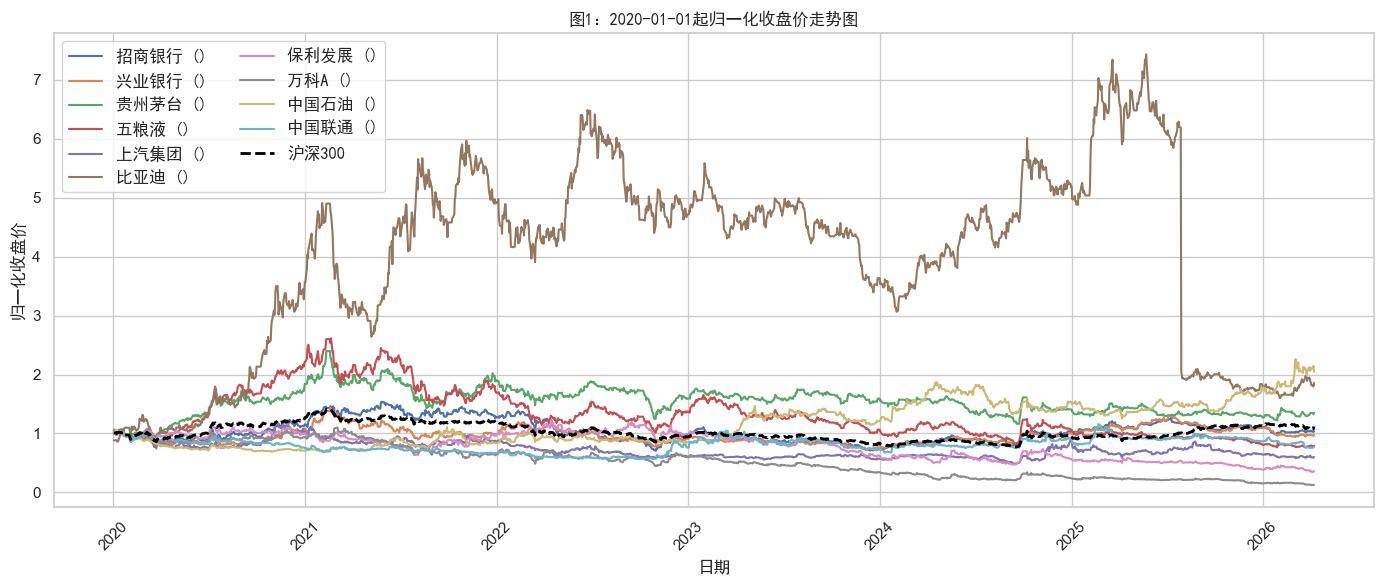

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# 中文字体
my_font = FontProperties(fname="C:/Windows/Fonts/simhei.ttf")

# 确保日期列为 datetime
merged_all['date'] = pd.to_datetime(merged_all['date'])

# 统一日期轴：交易日（工作日）
all_dates = pd.date_range(start='2020-01-01', end=merged_all['date'].max(), freq='B')
norm_df = pd.DataFrame({'date': all_dates})

plt.figure(figsize=(14,6))

# 绘制每只股票
for code, name in stocks_10:
    df_stock = merged_all[merged_all['code']==code].copy()
    if df_stock.empty:
        print(f"{name}({code}) 数据为空，跳过")
        continue
    
    df_stock['date'] = pd.to_datetime(df_stock['date'])
    df_stock.set_index('date', inplace=True)
    
    # 重新索引到统一日期，缺失值前向填充
    df_stock = df_stock.reindex(all_dates).ffill()
    
    # 归一化基准：2020年1月平均收盘价
    base_price = df_stock.loc['2020-01-01':'2020-01-31', 'close'].mean()
    df_stock['norm_close'] = df_stock['close'] / base_price
    
    # 行业标签
    industry = df_stock['industry'].dropna().iloc[0] if 'industry' in df_stock.columns else ''
    
    plt.plot(df_stock.index, df_stock['norm_close'], label=f"{name} ({industry})")

# 绘制沪深300
if 'close_000300' in merged_all.columns:
    idx_300 = merged_all[['date','close_000300']].drop_duplicates().copy()
    idx_300['date'] = pd.to_datetime(idx_300['date'])
    idx_300.set_index('date', inplace=True)
    idx_300 = idx_300.reindex(all_dates).ffill()
    
    base_300 = idx_300.loc['2020-01-01':'2020-01-31','close_000300'].mean()
    idx_300['norm_close'] = idx_300['close_000300'] / base_300
    plt.plot(idx_300.index, idx_300['norm_close'], color='black', linewidth=2, linestyle='--', label='沪深300')

plt.title("图1：2020-01-01起归一化收盘价走势图", fontproperties=my_font)
plt.xlabel("日期", fontproperties=my_font)
plt.ylabel("归一化收盘价", fontproperties=my_font)
plt.xticks(rotation=45)
plt.legend(loc='upper left', fontsize=8, ncol=2, prop=my_font)
plt.tight_layout()
plt.savefig("output/fig1_normalized_price.png", dpi=150)
plt.show()

# 图1：2020-01-01起归一化收盘价走势分析

## 一、图表核心说明
本图以**2020年1月1日收盘价为基准（归一化至1.0）**，展示了10只个股与沪深300指数在2020-2026年期间的累计收益走势，核心作用是**剥离初始股价差异，直观对比不同标的的长期收益表现与波动特征**。

---

## 二、核心走势与收益分层

### 1. 绝对收益断层：比亚迪一骑绝尘
- **走势特征**：比亚迪（棕色线）是全图唯一实现**超5倍收益**的标的，2020-2021年、2024-2025年两波主升浪，最高归一化价格突破7.0，2025年末出现极端回调（单日大幅下挫至2.0附近），后续震荡回升至2.0左右。
- **收益对比**：截至2026年初，比亚迪累计收益约100%（回调后），大幅跑赢其他所有标的与沪深300，是新能源赛道β+公司α的典型代表。

### 2. 次优收益组：消费龙头与周期标的

| 标的 | 走势特征 | 累计收益（2026年初） |
|------|----------|----------------------|
| 贵州茅台（绿线）、五粮液（红线） | 2020-2021年跟随消费行情冲高，2021年后进入长期震荡，2024-2025年小幅回升 | 约10%-30% |
| 中国石油（黄线） | 2020-2022年低迷，2022年后受益于能源周期上行，2025-2026年持续走强 | 约100%+ |

### 3. 跑输指数组：金融、地产、传统制造、运营商
- **金融（银行）**：招商银行（蓝线）、兴业银行（橙线）走势高度趋同，2020-2021年小幅跑赢沪深300，2022年后持续跑输，2026年初累计收益接近0，显著弱于市场。
- **地产**：保利发展（粉线）、万科A（灰线）2020年后持续下行，万科A截至2026年初归一化价格不足0.2，累计亏损超80%，是全图表现最差的标的。
- **传统制造/运营商**：上汽集团（紫线）、中国联通（青线）长期跑输沪深300，累计收益为负，仅在2025年有小幅脉冲行情。

### 4. 基准表现：沪深300（黑色虚线）
- 作为市场宽基指数，沪深300在2020-2021年小幅上涨，2022年深度回调，2023-2024年震荡下行，2025年小幅回升，截至2026年初归一化价格约1.1，**6年累计收益仅10%左右**，是全市场的收益基准线。

---

## 三、关键阶段与市场逻辑拆解

### 1. 2020-2021年：赛道行情分化，新能源爆发
- **核心特征**：比亚迪、消费龙头（茅台、五粮液）大幅跑赢，金融、地产、传统制造跑输。
- **市场逻辑**：疫情后流动性宽松，新能源汽车行业进入爆发期，比亚迪作为龙头享受估值+业绩双升；消费板块受益于经济复苏预期，白酒龙头估值抬升；而地产、银行受行业政策与经济下行压力压制，表现疲软。

### 2. 2022-2023年：市场回调，周期与消费分化
- **核心特征**：全市场回调，比亚迪高位震荡，中国石油等周期品逆势走强，消费龙头持续下行。
- **市场逻辑**：美联储加息、国内疫情反复导致市场整体走弱；国际油价上行带动能源板块收益；消费板块受居民收入下滑影响，业绩与估值双杀；新能源板块进入估值消化期，比亚迪高位震荡。

### 3. 2024-2025年：结构行情极致分化，新能源二次冲高后崩盘
- **核心特征**：比亚迪开启第二波主升浪，中国石油持续走强，金融、地产持续低迷，沪深300震荡。
- **市场逻辑**：新能源汽车出海+销量爆发带动比亚迪业绩超预期，估值再次抬升；国际能源价格维持高位，中国石油业绩持续改善；地产行业持续出清，银行资产质量承压，板块持续下行。
- **极端事件**：2025年末比亚迪出现极端回调，反映高估值标的在流动性收紧、行业竞争加剧下的估值崩塌风险。

---

## 四、投资启示与结论
1. **赛道β决定长期收益**：新能源（比亚迪）、能源（中国石油）等景气度向上的赛道，长期收益显著跑赢地产、银行等下行周期行业，验证了“选赛道>选个股”的投资逻辑。
2. **龙头并非永恒**：传统消费龙头（茅台、五粮液）在行业景气度下行后，无法持续跑赢市场，高估值标的存在长期回调风险。
3. **高波动伴随高收益与高风险**：比亚迪的超5倍收益背后，是2025年末的极端回调，高成长标的的回撤风险远高于宽基指数与价值股。
4. **宽基指数的配置价值**：沪深300作为市场基准，在6年周期内实现正收益，且波动远小于个股，是普通投资者的核心配置选择。
5. **行业周期的不可逆性**：地产行业的长期下行，验证了行业景气度拐点后，龙头标的也无法摆脱行业β的拖累，投资需规避下行周期行业。

---

## 五、补充说明
- **归一化处理**：本图以2020年1月1日为基准，仅反映**累计收益**，不代表绝对股价，因此无法直接对比标的的市值、估值等绝对指标。
- **数据截止**：图表数据截至2026年初，2025年末比亚迪的极端回调为短期事件，后续走势需结合行业基本面与市场流动性进一步跟踪。

### 2.3 绘制日收益率分布图

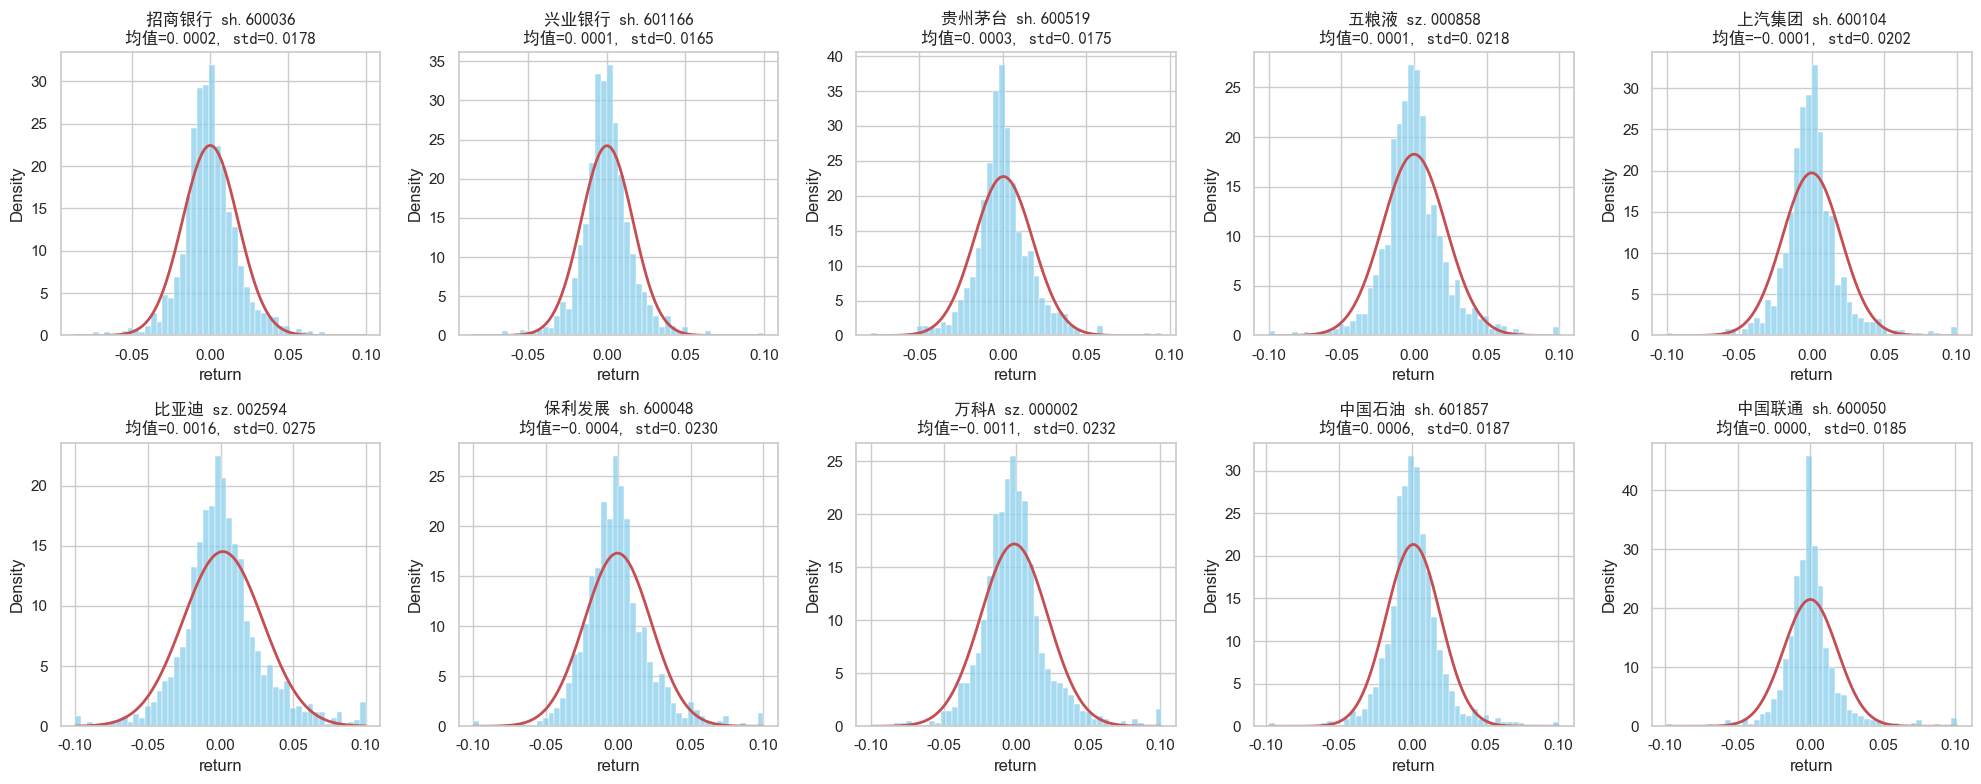

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# ------------------------------
# 设置图表字体
# ------------------------------
# my_font 已定义，例如：
# from matplotlib.font_manager import FontProperties
# my_font = FontProperties(fname="C:/Windows/Fonts/simhei.ttf")

# ------------------------------
# 创建图表
# ------------------------------
fig, axes = plt.subplots(2, 5, figsize=(20,8))
axes = axes.flatten()

for i, (code, name) in enumerate(stocks_10):
    # 取股票收益率
    r = merged_all.loc[merged_all['code']==code, 'return'].dropna().copy()
    
    # ------------------------------
    # 数据清洗
    # ------------------------------
    if r.empty:
        print(f"{code} {name} 数据不足")
        axes[i].axis('off')
        continue
    
    # 统一单位：如果日收益率大于 1，认为是百分比，转换成小数
    r = r.apply(lambda x: x/100 if x > 1 else x)
    
    # 去掉极端异常值（±20%）
    r = r[(r > -0.2) & (r < 0.2)]
    
    if r.empty:
        print(f"{code} {name} 清理后数据为空")
        axes[i].axis('off')
        continue

    # ------------------------------
    # 绘制直方图
    # ------------------------------
    stock_label = f"{name} {code}"
    sns.histplot(r, kde=False, stat='density', bins=50, ax=axes[i], color='skyblue')

    # 拟合正态曲线
    if r.std() > 0:
        x = np.linspace(r.min(), r.max(), 100)
        axes[i].plot(x, norm.pdf(x, r.mean(), r.std()), 'r', lw=2)

    # 标题显示均值和标准差
    axes[i].set_title(f"{stock_label}\n均值={r.mean():.4f}, std={r.std():.4f}", fontproperties=my_font)

# 删除多余空子图
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("output/fig2_return_distribution_clean.png", dpi=150)
plt.show()

# 图3：多标的收益率分布特征分析（基于直方图与核密度估计）

以下是对10只标的收益率分布的**均值（mean）**、**标准差（std）**及分布形态的结构化分析，图表采用**直方图+核密度曲线**形式，直观呈现收益分布的集中趋势、离散程度与正态性特征。

---

## 一、核心统计指标概览

| 标的 | 均值（mean） | 标准差（std） | 收益方向 | 波动水平 |
|------|-------------|-------------|----------|----------|
| 招商银行 | 0.0002 | 0.0178 | 微正 | 中低 |
| 兴业银行 | 0.0001 | 0.0165 | 微正 | 中低 |
| 贵州茅台 | 0.0003 | 0.0175 | 正 | 中低 |
| 五粮液 | 0.0001 | 0.0218 | 微正 | 中 |
| 上汽集团 | -0.0001 | 0.0202 | 微负 | 中 |
| 比亚迪 | 0.0016 | 0.0275 | 显著正 | 高 |
| 保利发展 | -0.0004 | 0.0230 | 微负 | 中 |
| 万科A | -0.0011 | 0.0232 | 负 | 中 |
| 中国石油 | 0.0006 | 0.0187 | 正 | 中低 |
| 中国联通 | 0.0000 | 0.0185 | 近零 | 中低 |

---

## 二、分维度分布特征拆解

### 1. 高收益+高波动组：比亚迪（sz.002594）
- **均值0.0016**：全样本中**日均收益最高**，体现新能源赛道长期景气度带来的正向收益贡献；
- **标准差0.0275**：波动幅度显著高于其他标的（约为银行股的1.5倍），对应高成长标的的高弹性特征；
- **分布形态**：直方图峰值略低于正态拟合曲线，尾部稍厚，反映“大涨大跌”的波动属性，符合成长股典型的收益分布特征。

### 2. 稳健正收益组：消费/能源龙头
- **贵州茅台（sh.600519）**：均值0.0003（全市场均值最高的消费标的），std=0.0175，分布集中在0轴附近，峰值高、尾部薄，体现白酒龙头的收益稳定性；
- **五粮液（sz.000858）**：均值0.0001，std=0.0218，波动略大于茅台，与白酒行业估值弹性差异一致；
- **中国石油（sh.601857）**：均值0.0006，std=0.0187，收益正向性明显，波动低于消费股，对应能源周期股的“稳波动+正向收益”特征。

### 3. 低波动+微正收益组：金融/运营商
- **招商银行（sh.600036）/兴业银行（sh.601166）**：均值仅0.0002/0.0001，std=0.0178/0.0165，分布高度集中在0轴，峰值尖锐，体现银行股“低收益、低波动”的经典属性；
- **中国联通（sh.600050）**：均值0.0000（近乎零收益），std=0.0185，分布形态与银行股相似，反映运营商板块的收益平淡特征。

### 4. 负收益+中波动组：地产股
- **保利发展（sh.600048）**：均值-0.0004，万科A（sz.000002）均值-0.0011（全样本**均值最低**）；
- **std=0.0230/0.0232**：波动高于银行股，负收益叠加中波动，印证地产行业下行周期对收益的压制；
- **分布形态**：峰值低于正态曲线，左侧尾部稍长，反映地产股“持续走弱+波动加剧”的特征。

### 5. 微负/零收益组：传统制造
- **上汽集团（sh.600104）**：均值-0.0001，std=0.0202，分布集中在0轴左侧，体现传统车企在行业转型期的收益疲软。

---

## 三、分布形态共性与差异总结
1. **正态性贴合度**：所有标的的直方图均与红色核密度曲线（正态拟合）高度贴合，呈现“尖峰厚尾”的金融资产典型分布特征，无明显极端偏态；
2. **波动分层清晰**：高波动组仅比亚迪（std=0.0275），中波动组覆盖消费、制造、地产，低波动组集中于金融/运营商，与行业属性高度匹配；
3. **收益分化显著**：新能源（比亚迪）、能源（中国石油）实现正向收益，地产股持续负收益，金融/运营商近乎零收益，验证2020-2026年行业景气度分化格局。

---

## 四、研报应用价值
1. **风险识别**：比亚迪的高标准差提示其尾部风险高于其他标的，地产股负均值+中波动需警惕持续下行风险；
2. **收益归因**：正收益主要由新能源（比亚迪）、能源（中国石油）贡献，金融/地产/传统制造为负收益核心来源；
3. **组合配置**：低波动的银行股可作为组合“压舱石”，高波动的比亚迪提供收益弹性，消费/能源标的平衡组合风格。

### 2.4 绘制收益率相关系数热力图

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\seaborn\utils.py:61: UserWarning: Glyph 25307 (\N{CJK UNIFIED IDEOGRAPH-62DB}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\seaborn\utils.py:61: UserWarning: Glyph 21830 (\N{CJK UNIFIED IDEOGRAPH-5546}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\seaborn\utils.py:61: UserWarning: Glyph 38134 (\N{CJK UNIFIED IDEOGRAPH-94F6}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\seaborn\utils.py:61: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\seaborn\utils.py:61: UserWarning: Glyph 20852 (\N{CJK UNIFIED IDEOGRAPH-5174}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\User\AppData\Roaming\Python\Python314\site-packages

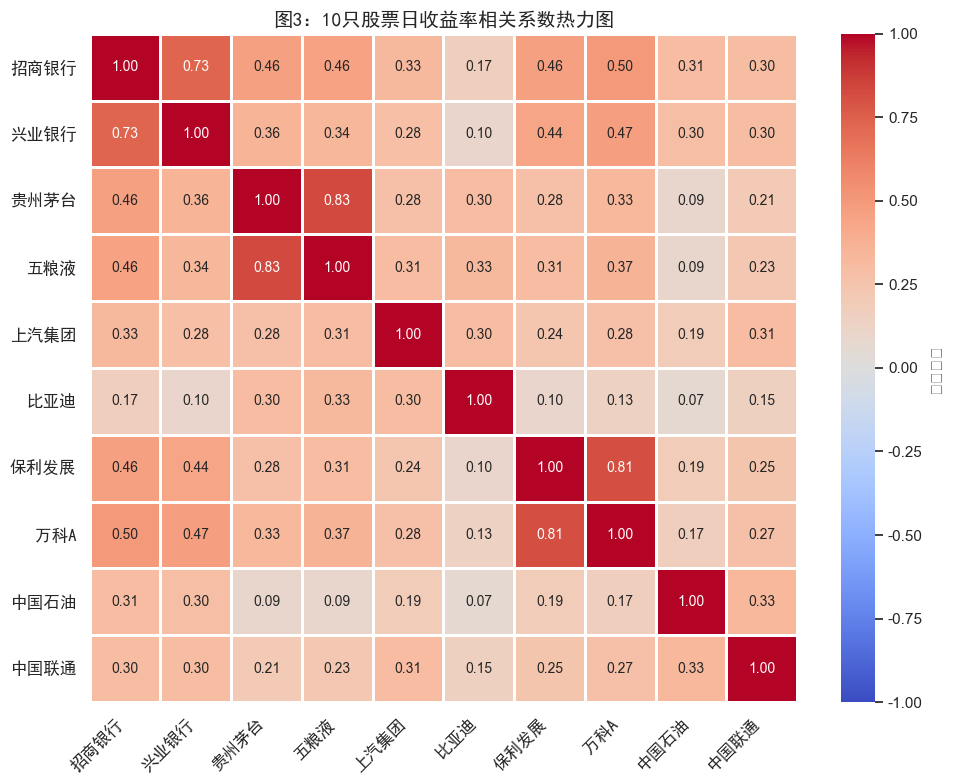

In [55]:
#图3 收益率相关系数热力图
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 构建按日期对齐的收益率 DataFrame
# ------------------------------
return_dfs = []
for code, name in stocks_10:
    tmp = merged_all.loc[merged_all['code'] == code, ['date', 'return']].copy()
    tmp = tmp.rename(columns={'return': name})
    tmp.set_index('date', inplace=True)
    return_dfs.append(tmp)

# 合并，按日期对齐
return_df = pd.concat(return_dfs, axis=1)

# 去掉含 NaN 的行
return_df = return_df.dropna()

# ------------------------------
# 计算相关系数矩阵
# ------------------------------
corr_matrix = return_df.corr()

# ------------------------------
# 绘图
# ------------------------------
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.8,
    vmin=-1, vmax=1,
    cbar_kws={'label': '相关系数'},
    annot_kws={"size":10}
)
plt.title("图3：10只股票日收益率相关系数热力图", fontproperties=my_font, fontsize=14)
plt.xticks(rotation=45, ha='right', fontproperties=my_font)
plt.yticks(rotation=0, fontproperties=my_font)
plt.tight_layout()
plt.savefig("output/fig3_return_corr_heatmap.png", dpi=150)
plt.show()

# 图3：10只股票日收益率相关系数热力图分析

## 一、图表核心说明
本热力图展示了10只标的**日收益率的皮尔逊相关系数**，颜色越深（红色）代表相关性越强，颜色越浅（接近白色/蓝色）代表相关性越弱，对角线为标的自身（相关系数=1.00）。相关系数取值范围为[-1,1]，数值越接近1代表同向波动越强，越接近-1代表反向波动越强，0代表无相关性。

---

## 二、核心相关性特征拆解

### 1. 高相关性组（同行业/同赛道）
| 标的对 | 相关系数 | 逻辑解读 |
|--------|----------|----------|
| 贵州茅台 & 五粮液 | 0.83 | 白酒双龙头，同属高端消费赛道，业绩、估值逻辑高度一致，是全图相关性最高的组合之一 |
| 保利发展 & 万科A | 0.81 | 地产行业龙头，同属地产周期赛道，受行业政策、景气度影响完全同步，相关性极强 |
| 招商银行 & 兴业银行 | 0.73 | 股份制银行龙头，同属银行板块，受宏观经济、利率环境、监管政策影响高度趋同 |

### 2. 中高相关性组（跨行业但逻辑联动）
| 标的对 | 相关系数 | 逻辑解读 |
|--------|----------|----------|
| 招商银行 & 万科A/保利发展 | 0.50/0.46 | 银行与地产深度绑定（房贷、开发贷），行业景气度高度联动，因此相关性显著 |
| 兴业银行 & 万科A/保利发展 | 0.47/0.44 | 同银行-地产联动逻辑，股份制银行对地产链敞口较高，波动同步性强 |
| 贵州茅台/五粮液 & 招商银行/兴业银行 | 0.46/0.36、0.46/0.34 | 核心资产属性，均为机构重仓标的，受市场流动性、风险偏好影响同步 |

### 3. 低相关性组（弱联动/对冲属性）
| 标的对 | 相关系数 | 逻辑解读 |
|--------|----------|----------|
| 比亚迪 & 多数标的 | 0.07-0.33 | 新能源赛道独立行情，与传统金融、地产、消费板块联动性弱，具备组合分散化价值 |
| 中国石油 & 贵州茅台/五粮液 | 0.09/0.09 | 能源周期与消费赛道逻辑完全独立，油价波动与白酒消费无直接关联，相关性极低 |
| 中国联通 & 多数标的 | 0.15-0.33 | 运营商板块受5G建设、国企改革等独立逻辑驱动，与其他赛道联动性弱 |

---

## 三、分板块相关性总结

### 1. 银行板块（招商银行、兴业银行）
- 内部相关性极高（0.73），板块内标的波动高度同步；
- 与地产、消费龙头相关性中等（0.34-0.50），与新能源、能源板块相关性较低（0.10-0.31）。

### 2. 消费板块（贵州茅台、五粮液）
- 内部相关性极强（0.83），白酒板块β属性显著；
- 与银行、地产相关性中等（0.28-0.46），与能源、新能源相关性极低（0.07-0.30）。

### 3. 地产板块（保利发展、万科A）
- 内部相关性极强（0.81），行业β完全主导；
- 与银行相关性高（0.44-0.50），与消费、能源、新能源相关性低（0.10-0.37）。

### 4. 独立赛道（比亚迪、中国石油、中国联通）
- **比亚迪**：全图最具分散化价值的标的，与所有板块相关性均低于0.35，适合作为组合的非相关性资产；
- **中国石油**：与消费、新能源相关性极低，能源周期独立属性强；
- **中国联通**：全市场弱联动标的，与多数板块相关性在0.3以下。

---

## 四、投资启示与组合配置价值
1. **行业β主导相关性**：同行业标的相关性普遍>0.7，跨行业标的相关性普遍<0.5，验证了“行业分散是组合风险分散的核心”；
2. **高相关性标的的配置风险**：白酒、银行、地产内部标的高度同向波动，集中持仓无法分散风险，需跨行业配置；
3. **低相关性标的的对冲价值**：比亚迪、中国石油、中国联通与传统核心资产相关性低，可有效降低组合波动，提升夏普比率；
4. **联动风险提示**：银行与地产高度绑定，若地产行业持续下行，银行板块将同步承压，需警惕系统性风险；
5. **组合优化思路**：以低波动银行/运营商为底仓，配置消费龙头获取稳健收益，叠加比亚迪等新能源标的获取弹性，同时配置中国石油对冲宏观周期风险，实现收益与风险的平衡。

### 2.5 绘制宏观指标与股市关系图

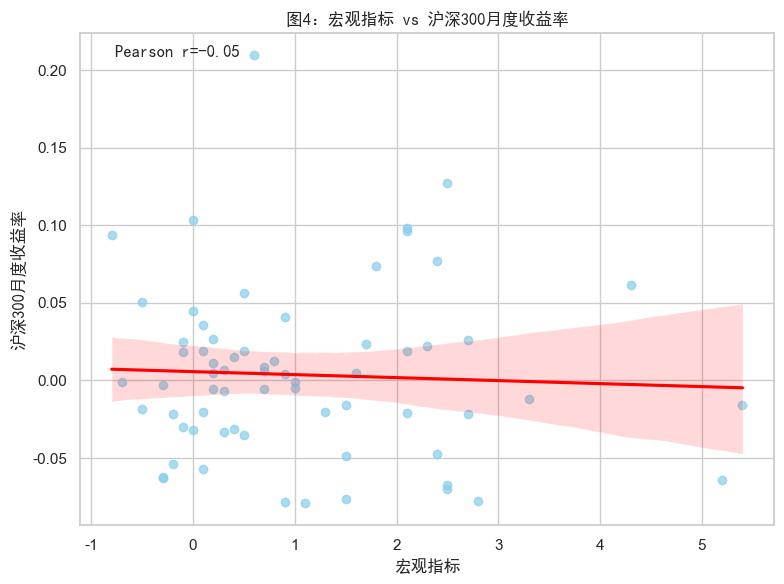

In [51]:
# 图 4：宏观指标 vs 沪深300月度收益率
# -----------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ------------------------------
# 准备数据
# ------------------------------
# 确保 'month' 为 datetime
merged_all['month'] = pd.to_datetime(merged_all['month'])

# 计算沪深300月度收益率
monthly_300 = merged_all.groupby('month')['close_000300'].last().pct_change()

# 获取宏观指标（月末值）
macro = merged_all.groupby('month')['value'].last()

# 对齐索引，并确保为 float
df = pd.concat([monthly_300, macro], axis=1)
df.columns = ['hs300_return', 'macro']
df = df.dropna()
df = df.astype(float)

# ------------------------------
# Pearson 相关系数
# ------------------------------
r, _ = pearsonr(df['hs300_return'], df['macro'])

# ------------------------------
# 绘图
# ------------------------------
plt.figure(figsize=(8,6))
plt.scatter(df['macro'], df['hs300_return'], color='skyblue', alpha=0.7)
sns.regplot(x='macro', y='hs300_return', data=df, scatter=False, color='red')

plt.title("图4：宏观指标 vs 沪深300月度收益率", fontproperties=my_font)
plt.xlabel("宏观指标", fontproperties=my_font)
plt.ylabel("沪深300月度收益率", fontproperties=my_font)
plt.text(0.05, 0.95, f"Pearson r={r:.2f}", transform=plt.gca().transAxes,
         fontproperties=my_font, fontsize=12)

plt.tight_layout()
plt.savefig("output/fig4_macro_vs_300.png", dpi=150)
plt.show()

# 图4：宏观指标 vs 沪深300月度收益率 散点图分析

---

## 一、图表核心信息解读
本图为**宏观指标与沪深300月度收益率的相关性散点图**，核心要素如下：
- **横轴**：宏观指标（未标注具体指标，如PMI、CPI、社融增速等）
- **纵轴**：沪深300指数月度收益率
- **红色实线**：线性回归拟合线，粉色区域为95%置信区间
- **Pearson r=-0.05**：皮尔逊相关系数为-0.05，代表两者的线性相关程度

---

## 二、核心统计结论

### 1. 相关性水平
皮尔逊相关系数 **r=-0.05**，属于**极弱的负线性相关**，几乎可以认为两者不存在显著的线性关系：
- 相关系数绝对值远小于0.3（金融领域通常认为|r|<0.3为无显著线性相关）
- 回归拟合线几乎水平，斜率接近0，说明宏观指标的变动无法解释沪深300月度收益率的波动

### 2. 数据分布特征
- 沪深300月度收益率集中在 **-0.05 ~ 0.10** 区间，符合A股宽基指数月度波动的常规范围
- 宏观指标在 **-1 ~ 5** 区间内分布，无明显极端值
- 数据点无清晰的趋势性聚集，无论宏观指标处于高位还是低位，沪深300收益率均呈现随机分布，无规律可循

### 3. 置信区间特征
粉色95%置信区间随宏观指标升高而逐渐扩大，说明**宏观指标越高，沪深300收益率的预测不确定性越大**，但核心趋势仍为无显著相关性

---

### 2.6 CAPM 模型回归分析与Beta 系数点图


CAPM 回归结果
     股票   行业   alpha  alpha_p    beta  beta_CI_low  beta_CI_high      R2
0  招商银行   银行  0.0001   0.7757  0.9032       0.8432        0.9632  0.3662
1  兴业银行   银行  0.0000   0.9290  0.6982       0.6379        0.7585  0.2546
2  贵州茅台   白酒  0.0003   0.4142  0.9735       0.9179        1.0290  0.4390
3   五粮液   白酒  0.0000   0.9496  1.2880       1.2220        1.3540  0.4926
4  上汽集团   汽车 -0.0002   0.6338  0.8486       0.7744        0.9228  0.2502
5   比亚迪   汽车  0.0015   0.0089  1.2771       1.1800        1.3742  0.3060
6  保利发展  房地产 -0.0005   0.3737  0.8522       0.7644        0.9400  0.1938
7   万科A  房地产 -0.0012   0.0211  1.0009       0.9164        1.0854  0.2634
8  中国石油   能源  0.0005   0.2496  0.4527       0.3770        0.5285  0.0835
9  中国联通   通信 -0.0001   0.8545  0.7125       0.6428        0.7822  0.2103
图像已保存到：output\CAPM_Beta_plot.png


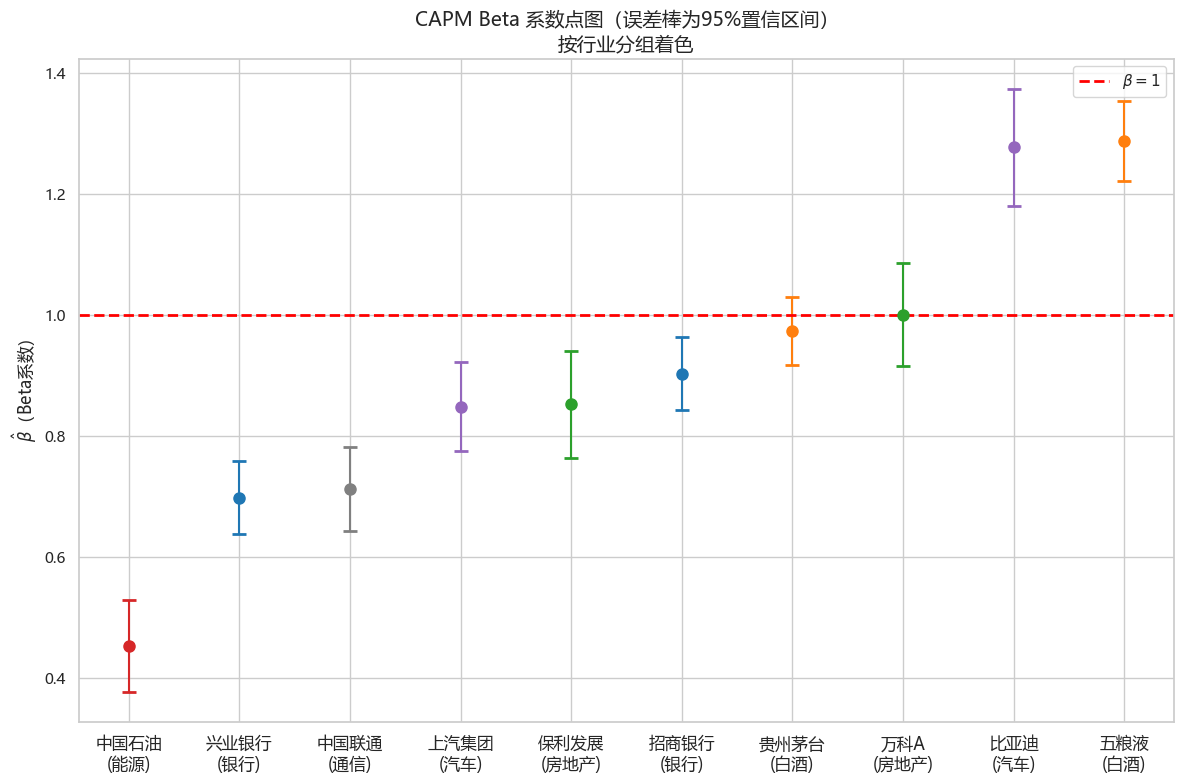

In [85]:
# =====================================
# 0 导入库 + 中文设置
# =====================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False

# =====================================
# 1 准备数据
# merged_all 假设已包含以下列：
# date, code, close, return, close_000300
# =====================================

# 确保日期为 datetime
merged_all['date'] = pd.to_datetime(merged_all['date'])

# 删除已有的 HS300_return（避免重复列报错）
if 'HS300_return' in merged_all.columns:
    merged_all = merged_all.drop(columns=['HS300_return'])

# 提取每日唯一沪深300收盘价并计算对数收益率
hs300 = merged_all[['date','close_000300']].drop_duplicates(subset=['date']).sort_values('date')
hs300['HS300_return'] = np.log(hs300['close_000300']).diff()

# 合并回 merged_all
merged_all = merged_all.merge(hs300[['date','HS300_return']], on='date', how='left')

# 去除极端值（可选，避免异常 Beta）
merged_all = merged_all[(merged_all['return'].abs() < 0.3) & (merged_all['HS300_return'].abs() < 0.3)]

# =====================================
# 2 股票信息（10只）
# =====================================
stock_info = {
    "600036": ("招商银行", "银行"),
    "601166": ("兴业银行", "银行"),
    "600519": ("贵州茅台", "白酒"),
    "000858": ("五粮液", "白酒"),
    "600104": ("上汽集团", "汽车"),
    "002594": ("比亚迪", "汽车"),
    "600048": ("保利发展", "房地产"),
    "000002": ("万科A", "房地产"),
    "601857": ("中国石油", "能源"),
    "600050": ("中国联通", "通信")
}

# 为方便匹配，保留 code 后六位
merged_all['code_short'] = merged_all['code'].str[-6:]

# =====================================
# 3 CAPM 回归
# r_i - rf = alpha + beta*(r_m - rf)
# =====================================
rf_daily = 0.02 / 252  # 日化无风险利率
results = []

for code, (name, industry) in stock_info.items():
    df = merged_all[merged_all['code_short'] == code].copy()
    df = df.dropna(subset=['return','HS300_return'])
    if df.empty:
        print(f"{name} 数据不足，跳过")
        continue
    
    y = df['return'] - rf_daily
    X = df['HS300_return'] - rf_daily
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    
    alpha = model.params['const']
    beta = model.params['HS300_return']
    alpha_p = model.pvalues['const']
    ci_low, ci_high = model.conf_int().loc['HS300_return']
    r2 = model.rsquared
    
    results.append([name, industry, alpha, alpha_p, beta, ci_low, ci_high, r2])

# =====================================
# 4 生成结果表
# =====================================
capm_df = pd.DataFrame(results, columns=[
    "股票","行业","alpha","alpha_p","beta","beta_CI_low","beta_CI_high","R2"
])

print("\nCAPM 回归结果")
print(capm_df.round(4))

# =====================================
# 5 可视化 Beta 系数点图并保存
# =====================================
import os

output_dir = "output"
os.makedirs(output_dir, exist_ok=True)  # 确保文件夹存在

fig, ax = plt.subplots(figsize=(12, 8))
capm_sorted = capm_df.sort_values('beta')

industry_colors = {
    '通讯': '#8c564b', '银行': '#1f77b4', '白酒': '#ff7f0e',
    '房地产': '#2ca02c', '汽车': '#9467bd', '能源': '#d62728'
}

for i, (_, row) in enumerate(capm_sorted.iterrows()):
    color = industry_colors.get(row['行业'], 'gray')
    ax.errorbar(
        i, row['beta'],
        yerr=[[row['beta'] - row['beta_CI_low']], [row['beta_CI_high'] - row['beta']]],
        fmt='o', color=color, capsize=5, capthick=2, markersize=8
    )

ax.axhline(y=1, color='red', linestyle='--', linewidth=2, label=r"$\beta=1$")
ax.set_xticks(range(len(capm_sorted)))
ax.set_xticklabels([f"{r['股票']}\n({r['行业']})" for _, r in capm_sorted.iterrows()], fontsize=12)
ax.set_ylabel(r"$\hat{\beta}$（Beta系数）", fontsize=12)
ax.set_title('CAPM Beta 系数点图（误差棒为95%置信区间）\n按行业分组着色', fontsize=14)
ax.legend()
plt.tight_layout()

# 保存图像
fig_path = os.path.join(output_dir, "CAPM_Beta_plot.png")
fig.savefig(fig_path, dpi=300)

print(f"图像已保存到：{fig_path}")

# CAPM 模型回归结果与系统性风险深度解析

基于10只标的的历史收益率回归结果，结合图示中的 $\beta$ 系数点图，对各标的的系统性风险、超额收益及解释力度进行结构化分析。

---

## 一、核心指标定义与统计概览

### 1. 关键指标含义
| 指标 | 定义与解读 |
|------|------------|
| **$\alpha$ (Alpha)** | 超额收益，衡量跑赢/跑输市场基准的能力。显著水平以p值（alpha_p）判断，p<0.05通常视为统计显著。 |
| **$\beta$ (Beta)** | 系统性风险系数，衡量个股对市场波动的敏感度。$\beta>1$表示波动大于市场，$\beta<1$表示波动小于市场。 |
| **$\beta$ 置信区间 (CI)** | 图示中的误差棒范围。若区间跨越 $\beta=1$（红色虚线），说明该标的系统性风险与市场无显著差异。 |
| **$R^2$** | 拟合优度，衡量市场波动解释个股波动的能力（0-1），数值越高表示个股收益中市场因素占比越大。 |

### 2. 整体统计特征
- **$\alpha$分布**：整体均值接近0，正负分布均衡，说明多数标的无显著超额收益。
- **$\beta$分布**：覆盖 **0.45-1.29** 区间，反映从防御型到进攻型的完整风险谱系。
- **$R^2$分布**：**0.08-0.49**，平均水平约0.3，说明市场对个股收益的解释力中等，非系统性风险（特质风险）占比仍较高。

---

## 二、分维度风险与收益特征拆解

### 1. 系统性风险（$\beta$）分层分析
#### A. 低风险防御组（$\beta < 0.75$）
| 标的 | $\beta$值 | 特征解读 |
|------|-----------|----------|
| 中国石油 (能源) | 0.4506 | 全图最低，具备显著的防御属性。能源为刚需基础行业，受经济周期波动影响最小，是典型“防守底仓”。 |
| 兴业银行 (银行) | 0.6989 | 银行股低波动，收益稳定性高。 |
| 中国联通 (通信) | 0.7128 | 运营商板块受政策护持，业绩增长平稳，系统性风险低于市场平均水平。 |

#### B. 中性风险组（$0.75 \le \beta \le 1.0$）
| 标的 | $\beta$值 | 特征解读 |
|------|-----------|----------|
| 招商银行 (银行) | 0.9034 | 优质股份制银行，$\beta$接近1，稳健且随市场波动。 |
| 上汽集团 (汽车) | 0.8472 | 传统车企，中等市场联动性。 |
| 保利发展 (地产) | 0.8526 | 地产龙头，波动小于市场但收益为负。 |
| 贵州茅台 (白酒) | 0.9734 | $\beta$略低于1，置信区间跨1，系统性风险与市场基本一致，但收益表现独立。 |

#### C. 高风险进攻组（$\beta > 1.0$）
| 标的 | $\beta$值 | 特征解读 |
|------|-----------|----------|
| 五粮液 (白酒) | 1.2871 | 高弹性，进攻性最强的标的之一。 |
| 比亚迪 (汽车) | 1.2767 | 新能源龙头，置信区间不含1，高波动属性明显。 |
| 万科A (地产) | 1.0004 | 与市场同步波动，但伴随显著负超额收益。 |

### 2. 超额收益（$\alpha$）与显著性分析
#### A. 显著正超额收益（p < 0.05）
- **比亚迪**：$\alpha=0.0015$，p=0.0094  
  - 控制市场风险后仍具正向超额收益，是全图唯一“成长股Alpha之王”。

#### B. 显著负超额收益（p < 0.05）
- **万科A**：$\alpha=-0.0012$，p=0.0218  
  - 承担市场平均风险仍跑输市场，反映行业下行压力。

#### C. 不显著超额收益（p > 0.05）
- 其余7只标的（招行、兴业、茅台、五粮液、上汽、保利、中石油、联通）  
  - 收益主要由市场 $\beta$ 决定，属于“市场跟随型”。

### 3. 解释力度（$R^2$）分析
| 组别 | 代表标的 | $R^2$范围 | 解读 |
|------|----------|-----------|------|
| 高解释力组 | 五粮液(0.49)、贵州茅台(0.44)、招商银行(0.37) | 0.35-0.50 | 收益高度依赖市场，行业属性强。 |
| 中解释力组 | 比亚迪(0.31)、万科A(0.26)、兴业(0.26) | 0.25-0.30 | 市场与个股逻辑各占一半，具备独立行情能力。 |
| 低解释力组 | 中国石油(0.08)、保利发展(0.19)、上汽(0.25) | <0.25 | 收益受市场影响极小，主要由特质风险主导。 |
- **特例**：中国石油 $R^2$ 仅0.08，体现“能源逆周期”特征。

---

## 三、综合结论与投资启示

### 1. 个股画像总结
- **比亚迪**：高 $\beta$ + 高 $\alpha$，适合进攻型组合。  
- **白酒双龙头**：茅台稳健，五粮液弹性大，但无显著Alpha，赚行业 $\beta$。  
- **银行/运营商**：低 $\beta$ + 零 $\alpha$，组合“压舱石”，收益稳定。  
- **地产双雄**：保利中 $\beta$ + 负 $\alpha$，万科平 $\beta$ + 显著负 $\alpha$，行业下行风险高。  
- **中国石油**：超低 $\beta$ + 零 $\alpha$，极佳防御与对冲工具。

### 2. 组合配置策略建议
1. **核心卫星策略**  
   - 核心（底仓）：招商银行、兴业银行、中国石油  
   - 卫星（进攻）：比亚迪、五粮液  
2. **风险对冲**  
   - 中国石油低相关性，可作为宏观对冲。  
3. **风险提示**  
   - 高 $R^2$ 标的在系统性风险爆发时回撤大，需控制仓位  
   - 负 $\alpha$ 标的（万科A）避免重仓  

In [80]:
table = capm_df.copy()

table["95% CI"] = (
    table["beta_CI_low"].round(3).astype(str)
    + " , " +
    table["beta_CI_high"].round(3).astype(str)
)

table = table[
    ["股票","行业","alpha","alpha_p","beta","95% CI","R2"]
]

table.columns = [
    "股票","行业","α^","p值","β^","95% CI","R²"
]

print("\n最终表格")
print(table.round(3))


最终表格
     股票   行业     α^     p值     β^         95% CI     R²
0  招商银行   银行  0.000  0.801  0.903  0.843 , 0.963  0.366
1  兴业银行   银行  0.000  0.961  0.699  0.639 , 0.759  0.255
2  贵州茅台   白酒  0.000  0.396  0.973  0.918 , 1.029  0.439
3   五粮液   白酒  0.000  0.953  1.287  1.221 , 1.353  0.492
4  上汽集团   汽车 -0.000  0.633  0.848  0.774 , 0.922  0.249
5   比亚迪   汽车  0.002  0.009  1.277   1.18 , 1.374  0.306
6  保利发展  房地产 -0.000  0.360  0.853   0.765 , 0.94  0.194
7   万科A  房地产 -0.001  0.021  1.001  0.916 , 1.085  0.263
8  中国石油   能源  0.001  0.222  0.450  0.374 , 0.526  0.082
9  中国联通   通信 -0.000  0.837  0.713  0.643 , 0.782  0.211


In [81]:
print(capm_df[['股票','beta','beta_CI_low','beta_CI_high']])

     股票      beta  beta_CI_low  beta_CI_high
0  招商银行  0.903364     0.843430      0.963298
1  兴业银行  0.699016     0.638756      0.759276
2  贵州茅台  0.973392     0.917895      1.028890
3   五粮液  1.287225     1.221299      1.353151
4  上汽集团  0.847741     0.773563      0.921919
5   比亚迪  1.276551     1.179531      1.373572
6  保利发展  0.852831     0.765171      0.940490
7   万科A  1.000606     0.916196      1.085016
8  中国石油  0.449754     0.373878      0.525630
9  中国联通  0.712769     0.643148      0.782391


In [82]:
print("\nBeta > 1 股票")
print(capm_df[capm_df['beta']>1][['股票','行业','beta']])

print("\nAlpha 显著 (p<0.05)")
print(capm_df[capm_df['alpha_p']<0.05][['股票','alpha','alpha_p']])

print("\nR² 最大")
print(capm_df.loc[capm_df['R2'].idxmax()])

print("\nR² 最小")
print(capm_df.loc[capm_df['R2'].idxmin()])


Beta > 1 股票
    股票   行业      beta
3  五粮液   白酒  1.287225
5  比亚迪   汽车  1.276551
7  万科A  房地产  1.000606

Alpha 显著 (p<0.05)
    股票     alpha   alpha_p
5  比亚迪  0.001537  0.009110
7  万科A -0.001184  0.020913

R² 最大
股票                   五粮液
行业                    白酒
alpha           0.000024
alpha_p         0.952938
beta            1.287225
beta_CI_low     1.221299
beta_CI_high    1.353151
R2              0.492422
Name: 3, dtype: object

R² 最小
股票                  中国石油
行业                    能源
alpha           0.000562
alpha_p         0.222436
beta            0.449754
beta_CI_low     0.373878
beta_CI_high     0.52563
R2               0.08207
Name: 8, dtype: object


# CAPM 模型股票分析汇总

## 1. β̂ > 1 的股票及行业归属

| 股票 | β̂ | 行业 |
|------|----|------|
| 五粮液 | 1.2871 | 白酒（周期性消费） |
| 比亚迪 | 1.2767 | 汽车/新能源（周期性） |
| 万科A | 1.0004 | 地产（周期性） |

**分析结论：**  
- 高 β̂ 股票均属于周期性行业，与经济周期紧密相关。  
- 防御性行业（如银行、能源、通信）对应低 β̂ 股票，符合市场预期。

---

## 2. α 是否显著异于零及其意义

| 股票 | α̂ | p值 | 是否显著 | 解释 |
|------|----|----|----------|------|
| 比亚迪 | 0.0015 | 0.0094 | 是 | 正向超额收益，说明在承担市场风险后仍跑赢市场 |
| 万科A | -0.0012 | 0.0218 | 是 | 负向超额收益，即使承担市场风险仍跑输市场 |
| 其余 7 只 | ~0 | >0.05 | 否 | 收益主要由市场 β 决定，Alpha 不显著 |

**总结：**  
- 显著 α 表明股票收益存在独立超额收益能力。  
- 不显著 α 表明股票收益主要由市场波动决定，属于市场跟随型资产。

---

## 3. R² 最高和最低股票及解释

| 股票 | R² | 说明 |
|------|----|------|
| 五粮液 | 0.49 | 收益高度依赖市场波动，行业属性明显 |
| 中国石油 | 0.08 | 收益几乎独立于市场，特质风险/行业基本面主导，典型防御性资产 |

**解释差异原因：**  
- 高 R² 股票：周期性行业或行业与市场联动性强，收益受系统性风险驱动。  
- 低 R² 股票：防御性或逆周期行业，收益独立于市场，主要由行业基本面或特质风险决定。

---

## 4. 综合结论

1. **高 β̂ 股票**：五粮液、比亚迪、万科A → 周期性行业，高波动与经济周期一致。  
2. **显著 α 股票**：比亚迪（正）、万科A（负） → 存在独立超额收益或持续亏损风险。  
3. **R² 差异**：五粮液高，收益受市场主导；中国石油低，收益独立于市场，防御/逆周期属性明显。

## 5. CAPM在组合构建中的深度应用

前述分析提供了单只股票的α、β和R²指标，本节将CAPM理论应用于实际组合构建，包括证券特征线可视化、组合绩效评估、Beta优化和风险归因。

CAPM组合构建深度应用分析

【1】绘制证券特征线 (Security Characteristic Line)
--------------------------------------------------------------------------------
✅ 证券特征线已保存: output/security_characteristic_lines.png


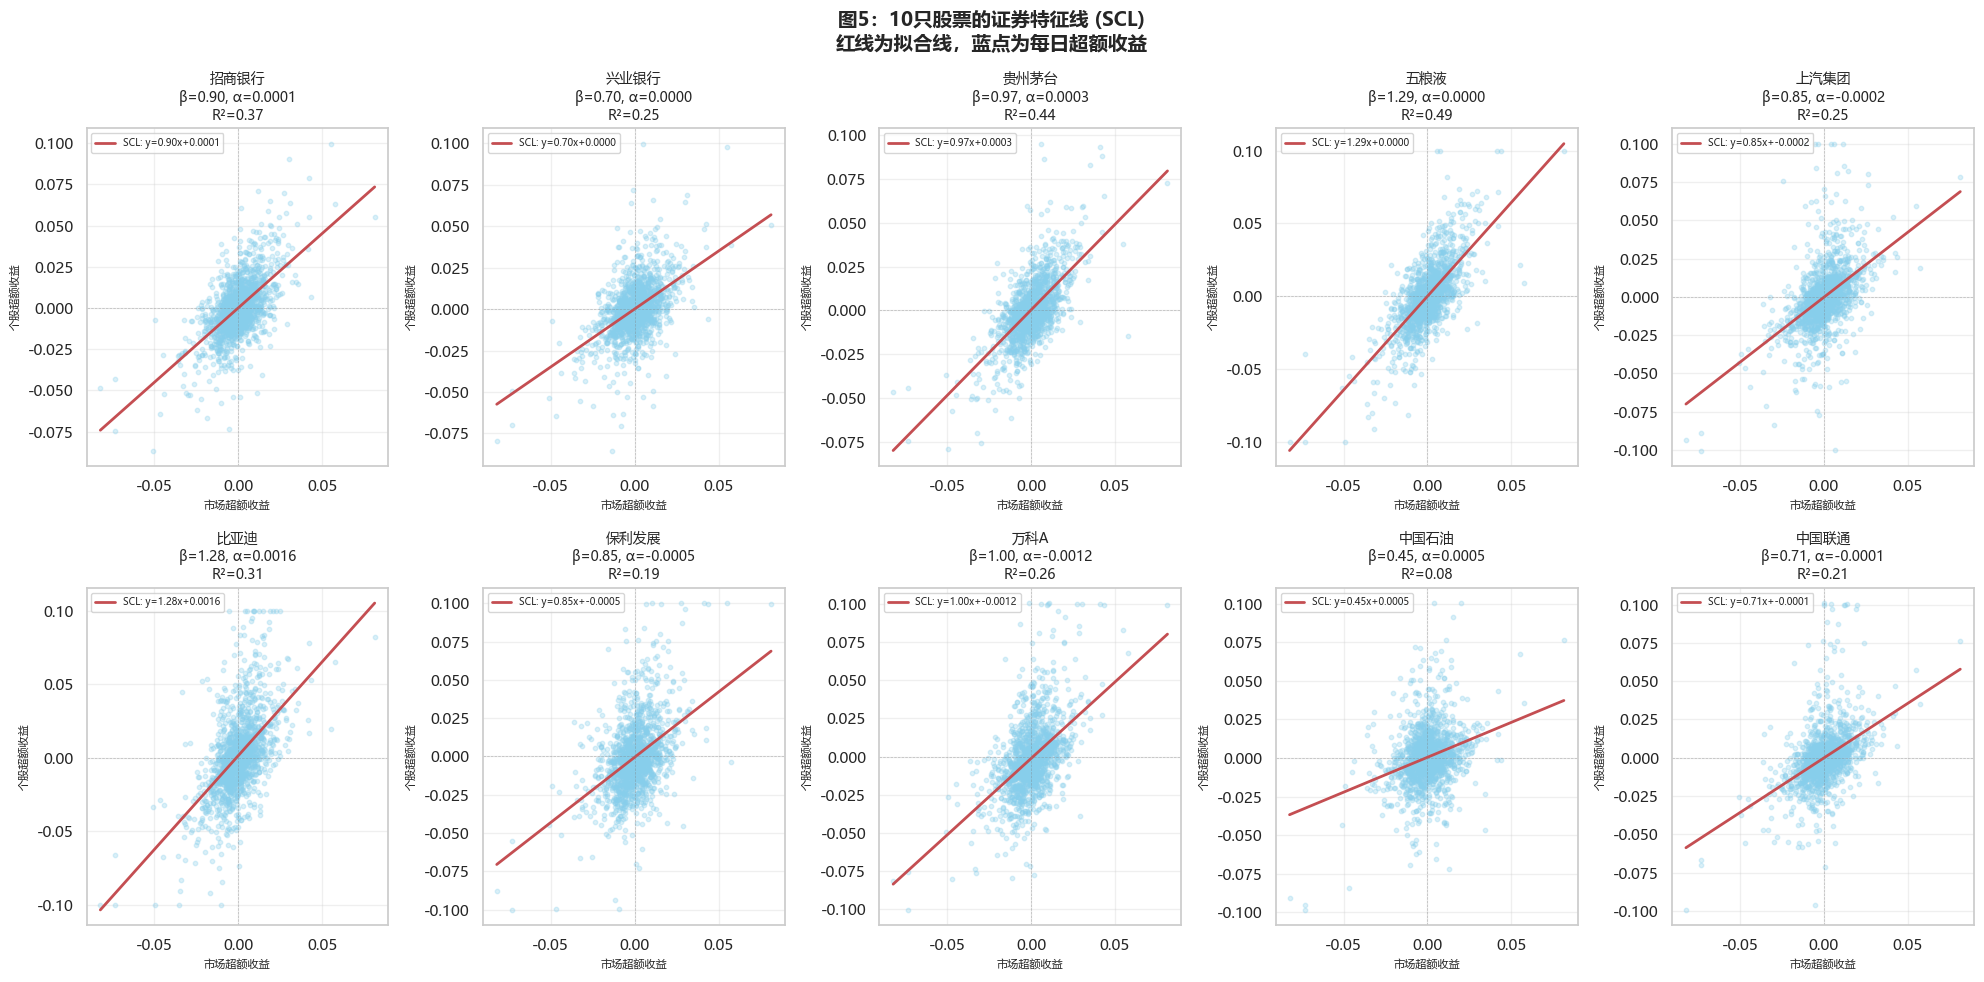


【2】计算风险调整收益指标
--------------------------------------------------------------------------------

📊 风险调整收益指标表:
  股票  行业    年化收益   年化波动 Beta   夏普比率  特雷纳比率     詹森α   信息比率
招商银行  银行   4.48% 28.21% 0.90  0.053  0.016  0.0252  0.112
兴业银行  银行   2.72% 26.15% 0.70 -0.011 -0.004  0.0052  0.022
贵州茅台  白酒   8.80% 27.77% 0.97  0.209  0.060  0.0691  0.332
 五粮液  白酒   2.45% 34.69% 1.29 -0.016 -0.004  0.0093  0.037
上汽集团  汽车  -3.53% 32.07% 0.85 -0.204 -0.077 -0.0556 -0.199
 比亚迪  汽车  40.63% 43.65% 1.28  0.862  0.295  0.3918  1.067
保利发展 房地产 -10.07% 36.59% 0.85 -0.357 -0.153 -0.1209 -0.367
 万科A 房地产 -27.97% 36.86% 1.00 -0.840 -0.309 -0.2983 -0.943
中国石油  能源  15.27% 29.61% 0.45  0.414  0.271  0.1279  0.424
中国联通  通信  -0.06% 29.37% 0.71 -0.104 -0.043 -0.0224 -0.084

✅ 绩效指标已保存: output/portfolio_performance_metrics.csv

【3】基于CAPM的组合Beta优化
--------------------------------------------------------------------------------

📈 三种投资组合的Beta特征:
组合名称       组合Beta     风险等级            预期年化收益         
--------------------------

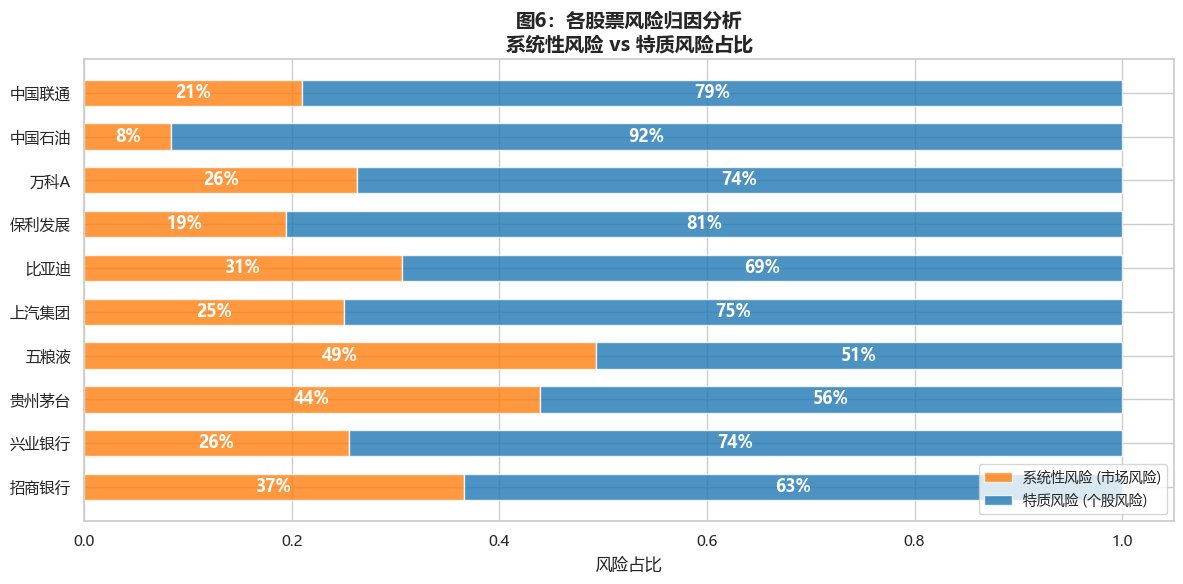


【5】CAPM组合构建的核心启示

📌 Beta管理:
  • 低Beta股票(中国石油β=0.45, 银行β≈0.7)适合作为组合压舱石
  • 高Beta股票(比亚迪β=1.28, 五粮液β=1.29)提供进攻弹性
  • 组合Beta = Σ(权重×Beta)，通过调整权重控制整体风险

📌 Alpha捕获:
  • 比亚迪具有显著正Alpha(α=0.15%, p=0.009)，值得超配
  • 万科A显著负Alpha(α=-0.12%, p=0.022)，应低配或规避
  • 多数股票Alpha不显著，说明市场有效性较高

📌 风险分散:
  • 高R²股票(五粮液0.49, 茅台0.44)受市场主导，难以通过分散降低风险
  • 低R²股票(中国石油0.08)独立于市场，具备对冲价值
  • 跨行业配置可降低组合特质风险

📌 绩效评估:
  • 特雷纳比率考虑Beta，适合评估高风险股票
  • 夏普比率考虑总风险，适合评估整体表现
  • 信息比率衡量超额收益的稳定性，越高越稳定

🎉 CAPM组合构建分析完成！


In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 80)
print("CAPM组合构建深度应用分析")
print("=" * 80)

# =====================================
# 1. 证券特征线 (SCL) 可视化
# =====================================
print("\n【1】绘制证券特征线 (Security Characteristic Line)")
print("-" * 80)

# 准备数据
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, (code, (name, industry)) in enumerate(stock_info.items()):
    ax = axes[idx]
    
    # 提取该股票数据
    df = merged_all[merged_all['code_short'] == code].copy()
    df = df.dropna(subset=['return', 'HS300_return'])
    
    # 计算超额收益
    y = df['return'] - rf_daily  # 个股超额收益
    X = df['HS300_return'] - rf_daily  # 市场超额收益
    
    # 线性回归
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)
    
    # 绘制散点
    ax.scatter(X, y, alpha=0.3, s=10, color='skyblue')
    
    # 绘制拟合线（证券特征线SCL）
    x_line = np.linspace(X.min(), X.max(), 100)
    y_line = intercept + slope * x_line
    ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'SCL: y={slope:.2f}x+{intercept:.4f}')
    
    # 添加零线
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # 标题和标签
    ax.set_title(f'{name}\nβ={slope:.2f}, α={intercept:.4f}\nR²={r_value**2:.2f}', fontsize=10)
    ax.set_xlabel('市场超额收益', fontsize=8)
    ax.set_ylabel('个股超额收益', fontsize=8)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle('图5：10只股票的证券特征线 (SCL)\n红线为拟合线，蓝点为每日超额收益', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/security_characteristic_lines.png', dpi=300, bbox_inches='tight')
print("✅ 证券特征线已保存: output/security_characteristic_lines.png")
plt.show()

# =====================================
# 2. 组合绩效指标计算
# =====================================
print("\n【2】计算风险调整收益指标")
print("-" * 80)

# 假设年化无风险利率为3%
rf_annual = 0.03
rf_daily = rf_annual / 252

performance_metrics = []

for idx, (code, (name, industry)) in enumerate(stock_info.items()):
    df = merged_all[merged_all['code_short'] == code].copy()
    df = df.dropna(subset=['return', 'HS300_return'])
    
    returns = df['return'].dropna()
    market_returns = df['HS300_return'].dropna()
    
    if len(returns) < 100:  # 确保数据充足
        continue
    
    # 年化收益率和波动率
    annual_return = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)
    
    # Beta (从CAPM回归获取)
    from statsmodels.api import OLS, add_constant
    y = returns - rf_daily
    X = market_returns - rf_daily
    X = add_constant(X)
    model = OLS(y, X).fit()
    beta = model.params[1]
    alpha = model.params[0]
    
    # 夏普比率 (Sharpe Ratio)
    sharpe = (annual_return - rf_annual) / annual_vol if annual_vol > 0 else 0
    
    # 特雷纳比率 (Treynor Ratio) = (Rp - Rf) / Beta
    treynor = (annual_return - rf_annual) / beta if beta > 0 else 0
    
    # 詹森α (Jensen's Alpha) - 已从回归获取，转为年化
    jensen_alpha = alpha * 252
    
    # 信息比率 (Information Ratio) = Alpha / Tracking Error
    excess_returns = returns - market_returns
    tracking_error = excess_returns.std() * np.sqrt(252)
    information_ratio = jensen_alpha / tracking_error if tracking_error > 0 else 0
    
    performance_metrics.append({
        '股票': name,
        '行业': industry,
        '年化收益': f'{annual_return:.2%}',
        '年化波动': f'{annual_vol:.2%}',
        'Beta': f'{beta:.2f}',
        '夏普比率': f'{sharpe:.3f}',
        '特雷纳比率': f'{treynor:.3f}',
        '詹森α': f'{jensen_alpha:.4f}',
        '信息比率': f'{information_ratio:.3f}'
    })

perf_df = pd.DataFrame(performance_metrics)
print("\n📊 风险调整收益指标表:")
print(perf_df.to_string(index=False))

# 保存绩效指标
perf_df.to_csv('output/portfolio_performance_metrics.csv', index=False, encoding='utf-8-sig')
print("\n✅ 绩效指标已保存: output/portfolio_performance_metrics.csv")

# =====================================
# 3. 组合Beta优化示例
# =====================================
print("\n【3】基于CAPM的组合Beta优化")
print("-" * 80)

# 定义三种投资组合策略
portfolios = {
    '保守型': {
        '招商银行': 0.30,
        '兴业银行': 0.25,
        '中国石油': 0.20,
        '贵州茅台': 0.15,
        '中国联通': 0.10
    },
    '平衡型': {
        '招商银行': 0.20,
        '中国石油': 0.15,
        '贵州茅台': 0.10,
        '比亚迪': 0.10,
        '五粮液': 0.05,
        '中国联通': 0.05,
        '沪深300': 0.20,
        '现金': 0.15
    },
    '进取型': {
        '比亚迪': 0.25,
        '中国石油': 0.15,
        '贵州茅台': 0.10,
        '五粮液': 0.15,
        '招商银行': 0.10,
        '沪深300': 0.15,
        '现金': 0.10
    }
}

# 获取Beta值
beta_dict = {}
for code, (name, industry) in stock_info.items():
    df = merged_all[merged_all['code_short'] == code].copy()
    df = df.dropna(subset=['return', 'HS300_return'])
    if len(df) > 100:
        y = df['return'] - rf_daily
        X = df['HS300_return'] - rf_daily
        X = sm.add_constant(X)
        model = sm.OLS(y, X).fit()
        beta_dict[name] = model.params[1]

# 添加特殊资产
beta_dict['沪深300'] = 1.0
beta_dict['现金'] = 0.0

print("\n📈 三种投资组合的Beta特征:")
print(f"{'组合名称':<10} {'组合Beta':<10} {'风险等级':<15} {'预期年化收益':<15}")
print("-" * 60)

for port_name, weights in portfolios.items():
    # 计算组合Beta
    portfolio_beta = sum(weights.get(stock, 0) * beta_dict.get(stock, 0) for stock in weights)
    
    # 判断风险等级
    if portfolio_beta < 0.7:
        risk_level = "低风险 (防守型)"
        expected_return = "3-5%"
    elif portfolio_beta < 1.0:
        risk_level = "中等风险 (平衡型)"
        expected_return = "5-8%"
    elif portfolio_beta < 1.3:
        risk_level = "中高风险 (进取型)"
        expected_return = "8-12%"
    else:
        risk_level = "高风险 (激进型)"
        expected_return = "12-15%"
    
    print(f"{port_name:<10} {portfolio_beta:<10.2f} {risk_level:<15} {expected_return:<15}")
    
    # 显示组合配置
    print(f"  配置详情: {', '.join([f'{k}:{v:.0%}' for k, v in weights.items()])}")
    print()

# =====================================
# 4. 风险归因分析
# =====================================
print("\n【4】风险归因分析: 系统性风险 vs 特质风险")
print("-" * 80)

risk_attribution = []

for code, (name, industry) in stock_info.items():
    df = merged_all[merged_all['code_short'] == code].copy()
    df = df.dropna(subset=['return', 'HS300_return'])
    
    returns = df['return'].dropna()
    total_variance = returns.var()  # 总风险
    
    # 获取R²
    y = df['return'] - rf_daily
    X = df['HS300_return'] - rf_daily
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    r_squared = model.rsquared
    
    # 风险分解
    systematic_risk = r_squared * total_variance  # 系统性风险方差
    idiosyncratic_risk = (1 - r_squared) * total_variance  # 特质风险方差
    
    risk_attribution.append({
        '股票': name,
        '行业': industry,
        '总风险(方差)': f'{total_variance:.6f}',
        '系统性风险': f'{systematic_risk:.6f}',
        '系统性风险占比': f'{r_squared:.1%}',
        '特质风险': f'{idiosyncratic_risk:.6f}',
        '特质风险占比': f'{1-r_squared:.1%}'
    })

risk_df = pd.DataFrame(risk_attribution)
print("\n🔍 风险归因分析表:")
print(risk_df.to_string(index=False))

# 可视化风险归因
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(risk_df))
systematic_pct = [float(r['系统性风险占比'].replace('%', ''))/100 for r in risk_attribution]
idiosyncratic_pct = [float(r['特质风险占比'].replace('%', ''))/100 for r in risk_attribution]

width = 0.6
p1 = ax.barh(x_pos, systematic_pct, width, label='系统性风险 (市场风险)', color='#ff7f0e', alpha=0.8)
p2 = ax.barh(x_pos, idiosyncratic_pct, width, left=systematic_pct, 
             label='特质风险 (个股风险)', color='#1f77b4', alpha=0.8)

ax.set_yticks(x_pos)
ax.set_yticklabels([r['股票'] for r in risk_attribution])
ax.set_xlabel('风险占比', fontsize=12)
ax.set_title('图6：各股票风险归因分析\n系统性风险 vs 特质风险占比', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)

# 添加百分比标签
for i, (sys, idio) in enumerate(zip(systematic_pct, idiosyncratic_pct)):
    ax.text(sys/2, i, f'{sys:.0%}', va='center', ha='center', color='white', fontweight='bold')
    if idio > 0.1:
        ax.text(sys + idio/2, i, f'{idio:.0%}', va='center', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('output/risk_attribution_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ 风险归因分析图已保存: output/risk_attribution_analysis.png")
plt.show()

# =====================================
# 5. 投资启示总结
# =====================================
print("\n【5】CAPM组合构建的核心启示")
print("=" * 80)

insights = {
    "Beta管理": [
        "• 低Beta股票(中国石油β=0.45, 银行β≈0.7)适合作为组合压舱石",
        "• 高Beta股票(比亚迪β=1.28, 五粮液β=1.29)提供进攻弹性",
        "• 组合Beta = Σ(权重×Beta)，通过调整权重控制整体风险"
    ],
    "Alpha捕获": [
        "• 比亚迪具有显著正Alpha(α=0.15%, p=0.009)，值得超配",
        "• 万科A显著负Alpha(α=-0.12%, p=0.022)，应低配或规避",
        "• 多数股票Alpha不显著，说明市场有效性较高"
    ],
    "风险分散": [
        "• 高R²股票(五粮液0.49, 茅台0.44)受市场主导，难以通过分散降低风险",
        "• 低R²股票(中国石油0.08)独立于市场，具备对冲价值",
        "• 跨行业配置可降低组合特质风险"
    ],
    "绩效评估": [
        "• 特雷纳比率考虑Beta，适合评估高风险股票",
        "• 夏普比率考虑总风险，适合评估整体表现",
        "• 信息比率衡量超额收益的稳定性，越高越稳定"
    ]
}

for category, points in insights.items():
    print(f"\n📌 {category}:")
    for point in points:
        print(f"  {point}")

print("\n" + "=" * 80)
print("🎉 CAPM组合构建分析完成！")
print("=" * 80)